In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import sys, os
from glob import glob 
# Gross fix this
sys.path.append(os.path.dirname(os.getcwd())); from utils import *

plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

from scipy.signal import find_peaks


from base64 import b64encode
from IPython.display import HTML
def show_video(video_path):
    video_file = open(video_path, "r+b").read()
    video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
    return HTML(f"""<video width="640" height="480" autoplay loop controls><source src="{video_url}"></video>""")


In [2]:
good_data_only = [
    ('20211014T120100Z', 'north half good'),
    ('20211014T123100Z', 'north half good. lighting exposure changes'),
    ('20211013T170100Z', 'some lighting'), 
    ('20211014T130100Z', 'north only, some low contrast'),
    ('20211028T153100Z', '')
]
array_8m = xr.load_dataset('../../../data/FRF-ocean_waves_8m-array_202110.nc')


In [3]:
# Go through and find all the > SECONDS duration clips
data = []
SECONDS = 60
for time, _ in good_data_only:
    file = os.path.join('../../../data/argus', f'ArgusFF_{time}_RectifiedVideo.avi')
    N, W, H, FPS = get_video_shape(file)
    timestack = load_frames(file, dtype=np.uint8)[:, 500:1000, :]
    
    bad_data = np.sum(timestack == 0, axis=2).sum(axis=1)
    good_data = bad_data == bad_data.min()
    edges = np.convolve((np.convolve(good_data, np.ones(FPS * SECONDS + 1)) == FPS * SECONDS + 1),np.array([1, -1]))

    start = np.where(edges == 1)[0]
    end =   np.where(edges == -1)[0]

    data.append({
                'filename': os.path.abspath(file),
                'key': time,
                'good_data': list(zip(start, end)) 
            },
    )
    break
    del timestack
    print(data[-1], (end-start)/FPS/60, 'min')

3.072gb allocated


Building Timestack:   0%|          | 0/3840 [00:00<?, ?it/s]

Building Timestack: 100%|██████████| 3840/3840 [00:13<00:00, 289.03it/s]


In [7]:
def lambda_c_algorithm(timestack):
    N, M, _ = timestack.shape
    result = np.zeros_like(timestack, dtype=bool)
    
    for i in tqdm(range(M), desc="Processing alongshore"):
        diff = timestack[1:, i] - timestack[:-1, i]
        result[:, i, :] = remove_loose_pixels_not_in_line(
                            detect_leading_edges(
                                # Threshold on brightness
                                timestack[:, i] >= np.percentile(timestack[:, i], 95), axis=0),
                            min_line_length=3, eps=5, min_samples=5)
        
        # And optionally on gradient? This is picking up lots of stuff offshore which isn't ideal
        # result[1:, i, :] |= remove_loose_pixels_not_in_line(diff > np.percentile(diff, 90, axis=1)[:, np.newaxis], 15)

    for i in tqdm(range(N), desc="Processing time"):
        result[i] = remove_loose_pixels_not_in_line(
            detect_leading_edges(result[i], axis=1),
            min_line_length=3, eps=3, min_samples=5
        )

    # for i in tqdm(range(N), desc="Removing loose pixels"):
    #     result[i] = remove_loose_pixels(result[i], 5)

    breaker_labels = filter_and_label_spatiotemporal_propagation(result, min_size=6, time_window=3, space_window=5)
    
    return breaker_labels != 0

In [8]:
def show_breakers(timestack, breakers, i=200):
    frame = np.stack((timestack[i],)*3, axis=-1).astype(np.uint8)
    frame[ndi.binary_dilation(breakers[i]!=0, iterations=2), :] = (255, 0, 0)
    plt.figure(figsize=(30, 6))
    plt.imshow(np.swapaxes(frame, 0, 1))
    
def show_breakers_on_frame(frame, i, breakers):
    if np.any(breakers[i] != 0):
        frame[ndi.binary_dilation(breakers[i]!=0, iterations=2)] = np.array(([0, 0, 255]))
    return frame

In [ ]:
def find_peaks(timestack, c=5):
    peaks = []
    for i in tqdm(range(0, 1600)):
        p = np.argsort(
                ndi.sobel(timestack[:, i, :].T),
            axis=0)[::-1][:c]
        peaks.append(
            np.array(p)
        )

    peaks = np.array(peaks)
    return peaks    
peaks = find_peaks(timestack)

In [189]:
Tp = array_8m.sel(time=pd.to_datetime(vid['key']).tz_localize(None), method='nearest').waveTp.item()

result = running_qb(breakers.astype(np.float64), Tp, window_size=FPS*30)


In [198]:
plt.figure()
plt.imshow(result[100])
plt.colorbar()

In [192]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Flatten the data and create histogramddd
flat_data = result.flatten()
hist, bin_edges = np.histogram(flat_data, bins=100, range=(0, 0.1))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Prepare data for GMM
# Limit the maximum count to keep dataset size manageable
max_count = 1000
scaled_hist = (hist / hist.max() * max_count).astype(int)
X = np.repeat(bin_centers, scaled_hist).reshape(-1, 1)

# Fit Gaussian Mixture Model
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X)

# Generate points from the GMM
x = np.linspace(0, 0.1, 1000).reshape(-1, 1)
logprob = gmm.score_samples(x)
responsibilities = gmm.predict_proba(x)



In [206]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.hist(flat_data, bins=100, density=True, alpha=0.7)
plt.plot(x, np.exp(logprob), 'k-', label='GMM')
plt.plot(x, np.exp(logprob) * responsibilities[:, 0], 'r--', label='Gaussian 1')
plt.plot(x, np.exp(logprob) * responsibilities[:, 1], 'b--', label='Gaussian 2')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
# plt.xlim(0, 0.1)
plt.title('Gaussian Mixture Model Fit')
# plt.gca().set_yscale('log')
# plt.ylim(1e-1, 1e2)

# Print the parameters of the two Gaussians
for i, (mean, covar) in enumerate(zip(gmm.means_, gmm.covariances_)):
    print(f'Gaussian {i+1}:')
    print(f'  Mean = {mean[0]:.6f}')
    print(f'  Std Dev = {np.sqrt(covar[0][0]):.6f}')
    print(f'  Weight = {gmm.weights_[i]:.6f}')
    plt.axvline(mean)
    
plt.show()
    

Gaussian 1:
  Mean = 0.000601
  Std Dev = 0.001100
  Weight = 0.966427
Gaussian 2:
  Mean = 0.006047
  Std Dev = 0.002078
  Weight = 0.033573


/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_18883/55253394.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [211]:
# Apply Gaussian smoothing to result[0]
i=300
mean = gmm.means_[1][0]
covar = gmm.covariances_[1]
print(mean)
print(covar)

smoothed_data = ndi.gaussian_filter(result[i], sigma=2)

# Create the contour
fig, ax = plt.subplots(figsize=(10, 8))
contour = ax.contour(smoothed_data, levels=[ mean - 2 * np.sqrt(covar[0][0])], colors='red', linewidths=2)

# Extract contour lines
contour_lines = contour.allsegs[0]

# Plot the original data
ax.imshow(result[0], cmap='viridis')

# Plot the smoothed contour lines
for line in contour_lines:
    ax.plot(line[:, 0], line[:, 1], color='red', linewidth=2)

ax.set_title(f'Smoothed Contour at Second Gaussian Mean ({mean:.4f})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.colorbar(ax.imshow(result[i], cmap='viridis'), label='Original Data Values')
plt.show()

# Create a binary image with the contour
contour_image = np.zeros_like(result[i], dtype=bool)
for line in contour_lines:
    rr, cc = np.round(line[:, 1]).astype(int), np.round(line[:, 0]).astype(int)
    contour_image[rr, cc] = True

# Plot the contour as a binary image
plt.figure(figsize=(10, 8))
plt.imshow(contour_image, cmap='binary')
plt.title(f'Contour Line at Second Gaussian Mean ({mean:.4f})')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


0.0060470787785429645
[[4.31621054e-06]]


/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_18883/4152769999.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_18883/4152769999.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [214]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy import ndimage as ndi

# Assuming result, mean, and covar are already defined

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
contour_lines = []
contours = np.zeros_like(breakers, dtype=bool)

contour_image = np.zeros_like(result[0], dtype=bool)

def update(frame):
    ax1.clear()
    ax2.clear()
    
    # Apply Gaussian smoothing to result[frame]
    smoothed_data = ndi.gaussian_filter(result[frame], sigma=2)
    
    # Create the contour
    contour = ax1.contour(smoothed_data, levels=[mean - 2 * np.sqrt(covar[0][0])], colors='red', linewidths=2)
    
    # Extract contour lines
    contour_lines = contour.allsegs[0]
    
    # Plot the original data
    im = ax1.imshow(result[frame], cmap='viridis')
    
    # Plot the smoothed contour lines
    for line in contour_lines:
        ax1.plot(line[:, 0], line[:, 1], color='red', linewidth=2)
    
    ax1.set_title(f'Frame {frame}: Smoothed Contour at Second Gaussian Mean ({mean:.4f})')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    
    # Create a binary image with the contour
    contour_image = np.zeros_like(result[frame], dtype=bool)
    for line in contour_lines:
        rr, cc = np.round(line[:, 1]).astype(int), np.round(line[:, 0]).astype(int)
        contour_image[rr, cc] = True
    contours[frame] = contour_image
    
    # Plot the contour as a binary image
    ax2.imshow(contour_image, cmap='binary')
    ax2.set_title(f'Second {frame/FPS}: Contour Line - 30s avg. Qb surfzone GMM Surfzone Definition ({mean:.4f})')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    
    return ax1, ax2

# Create the animation
anim = FuncAnimation(fig, update, frames=len(result), interval=1, blit=False)

# Save the animation (uncomment the line below to save)
# anim.save('contour_evolution.mp4', writer='ffmpeg', fps=5)

plt.tight_layout()
plt.show()

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_18883/1944947599.py:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [258]:
write_sequence_to_mp4(normalize(contours.astype(np.uint8)), 'contours.mp4')

100%|██████████| 1043/1043 [00:08<00:00, 117.85it/s]


In [269]:
last_true = contours.shape[2] - np.argmax(np.flip(contours, axis=2), axis=2) - 1

In [304]:
plt.figure()
plt.imshow(last_true, cmap='hot', vmin=150, vmax=250)
plt.colorbar()
plt.xlim(100, 300)
plt.ylim(60, 900)

(60.0, 900.0)

In [302]:
ymin=0
ymax=300

fig, ax = plt.subplots()
colors = plt.cm.viridis(np.linspace(0, 1, ymax-ymin))

for i, y in enumerate(np.arange(ymin, ymax)):
    ax.plot(np.arange(len(last_true))/2, last_true[:, y], c=colors[i], alpha=0.5)

norm = Normalize(vmin=ymin, vmax=ymax)
sm = ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Along-shore Location')


plt.xlim(60, 300)
plt.ylim(100, 300)
plt.xlabel('Seconds')
plt.ylabel('Cross-shore Surf Zone Onset')

Text(0, 0.5, 'Cross-shore Surf Zone Onset')

In [272]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalizea

fig, ax = plt.subplots(figsize=(20, 4))
colors = plt.cm.viridis(np.linspace(0, 1, len(contours)))
ym=1600
tmin=60
tmax=800
for i, c in enumerate(last_true[tmin:tmax]):
    # if i%3==0:
    mask = (c[:ym] > 0) & (c[:ym] < 480)
    ax.scatter(np.arange(ym)[mask], c[:ym][mask], c=colors[i], s=2)

norm = Normalize(vmin=tmin, vmax=tmax)
sm = ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Index')
plt.gca().set_aspect(1)

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_18883/931167907.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(np.arange(ym)[mask], c[:ym][mask], c=colors[i], s=2)


  0%|          | 0/1600 [00:00<?, ?it/s]

100%|██████████| 1600/1600 [00:03<00:00, 432.60it/s]


<Figure size 1000x1000 with 0 Axes>

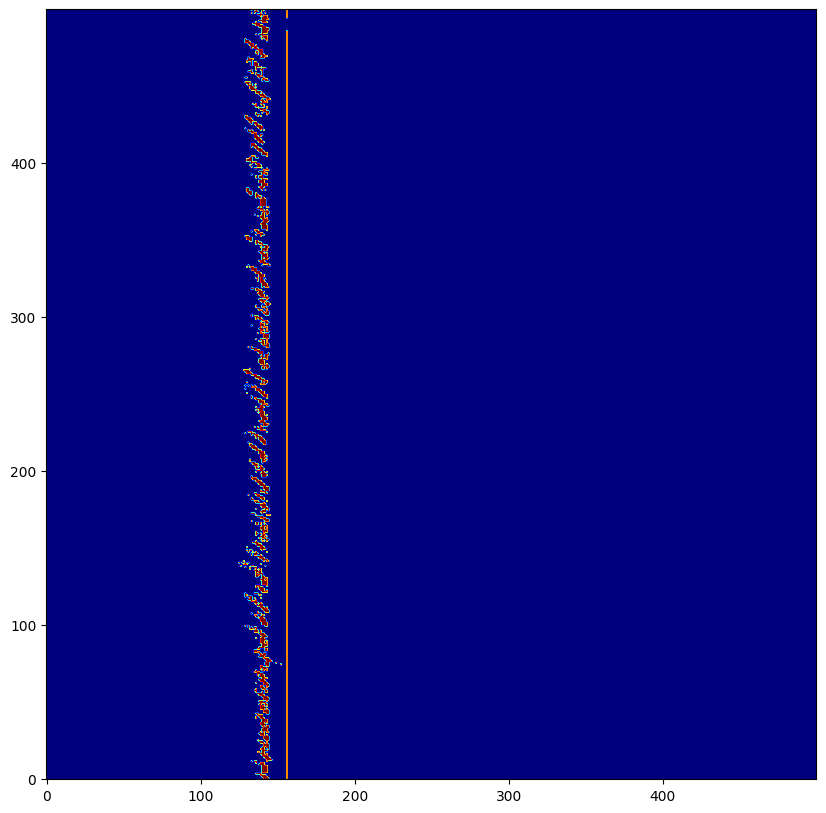

<Figure size 1000x1000 with 0 Axes>

In [241]:
from peakutils.baseline import baseline

def baseline(x, deg):
    return np.polyval(np.polyfit(np.arange(len(x)), x, deg), np.arange(len(x)))

def stringari_intensity_peaks(timestack, n=10, stride=1, use_baseline=True, use_find_peaks=False, prominence=255/10, height=255/2):
    time, along, cross = timestack.shape
    breakers = np.zeros_like(timestack, dtype=np.uint8)

    for y in tqdm(range(0, along, 1)):
        ts = timestack[:, y, :].copy()  # Create a copy to avoid modifying the original data
        
        for t in range(time):
            if use_baseline:
                ts[t] = ts[t] - baseline(ts[t], 2)
            
            if use_find_peaks:
                peaks, _ = find_peaks(ts[t], height=height, prominence=prominence)
                peak_indices = peaks[:n]  # Limit to top n peaks
            else:
                peak_indices = np.argsort(ts[t])[::-1][:n]
            
            for i, p in enumerate(peak_indices):
                breakers[t, y, p] = i + 1  # Index starts from 1

    return breakers
def stringari_sobel_peaks(timestack, n=10, use_baseline=True):
    time, along, cross = timestack.shape
    breakers = np.zeros_like(timestack, dtype=np.uint8)

    # For each cross-shore transect
    for y in tqdm(range(along)):
        ts = ndi.sobel(timestack[:, y, :])
        # At teach time
        for t in range(time):
            # Pick the N highest intensity points as breaking
            b = np.zeros_like(ts[t])
            if use_baseline:
                b = baseline(ts[t], 2)
        
            p = np.argsort(np.diff(ts[t] - b))[::-1][:n]
            for p in p:
                breakers[t, y, p] = p+1

    return breakers

def stringari_peaks_percentile(timestack, n=10):
    time, along, cross = timestack.shape
    breakers = np.zeros_like(timestack, dtype=np.uint8)

    # For each cross-shore transect
    for y in tqdm(range(along)):
        ts = timestack[:, y, :] 
        percentile = (1 - (n / 500)) * 100
        breakers[:, y, :] = ts > np.percentile(ts, percentile, axis=1)[:, np.newaxis]
         
    return breakers

breakers = stringari_intensity_peaks(timestack[:500], n=5, use_find_peaks=False, prominence=25)
pbreakers = stringari_peaks_percentile(timestack[:500], n=5)
plt.figure(figsize=(10, 10))
plt.imshow(breakers[:, 1000]!=0, cmap='jet')
plt.figure(figsize=(10, 10))
# plt.imshow(pbreakers[:, 500], cmap='jet')
# plt.figure(figsize=(10, 10))
# plt.imshow((breakers[:, 500] == 0).astype(int) - (pbreakers[:, 500] == 0), cmap='jet')
# plt.colorbar()

In [250]:
write_sequence_to_mp4((timestack).astype(np.uint8) , f'{vid['key']}_breakers_highlight_{start}.mp4', fn=show_breakers_on_frame, FPS=FPS*5, data=pbreakers)

  0%|          | 0/1043 [00:00<?, ?it/s]

228


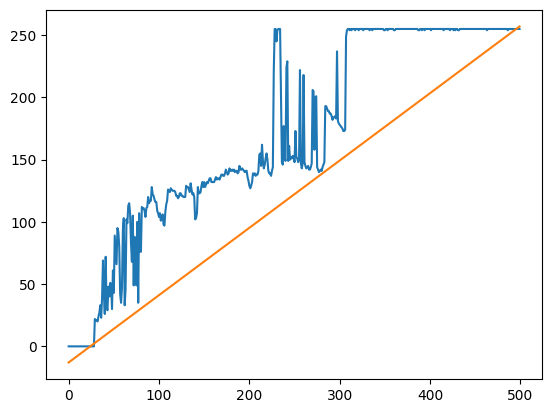

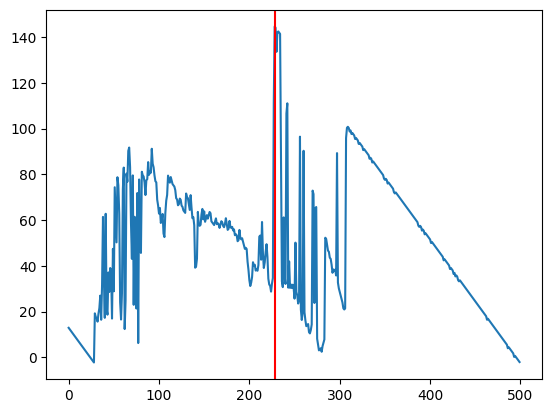

In [246]:
from peakutils.baseline import baseline

i = 1200
plt.plot(timestack[10, i, :])
plt.plot(baseline(timestack[10, i, :], 1))
plt.figure()
plt.plot(
    timestack[10, i, :] -     
    baseline(timestack[10, i, :], 1)
)


for p in find_peaks(timestack[10, i, :] -     
    baseline(timestack[10, i, :], 2), height=255/2, prominence=255/10)[0]:
    print(p)
    plt.axvline(p, c='r')